In [57]:
# Hyperparameter

train_start_year = '2020'
train_end_year = '2024'

test_start_year = '2025'
test_end_year = '2025'

In [58]:
# Data import
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

files = glob.glob("data/raw/*.csv")

dfs = []

for file in files:
    
    # skip bad header rows by searching for real header line
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # find the row where actual header starts
    header_idx = None
    for i, line in enumerate(lines):
        if "Date" in line and "Open" in line and "Close" in line:
            header_idx = i
            break

    if header_idx is None:
        continue  # skip broken file

    # read correctly
    df = pd.read_csv(file, skiprows=header_idx)

    # normalize column names
    df.columns = [c.strip().lower() for c in df.columns]

    # keep only required columns (ignore tradecount, etc.)
    required = ["date", "symbol", "open", "high", "low", "close"]

    # handle volume column name variations
    volume_col = None
    for c in df.columns:
        if "volume usdt" in c.lower() or "volume usd" in c.lower():
            volume_col = c

    if volume_col is None:
        continue  # skip if no volume

    df = df[required + [volume_col]]

    df = df.rename(columns={volume_col: "volume"})

    # convert date
    df["date"] = pd.to_datetime(df["date"])

    # drop rows where close is missing (extra safety)
    df = df.dropna(subset=["close"])

    dfs.append(df)

# combine all coins
data = pd.concat(dfs, ignore_index=True)

# set index
data = data.set_index(["date", "symbol"]).sort_index()

print(data)

                         open       high        low      close        volume
date       symbol                                                           
2017-08-17 BTCUSDT  4261.4800  4485.3900  4200.7400  4285.0800  3.454770e+06
           ETHUSDT   301.1300   312.1800   298.0000   302.0000  2.154655e+06
2017-08-18 BTCUSDT  4285.0800  4371.5200  3938.7700  4108.3700  5.086958e+06
           ETHUSDT   302.0000   311.7900   283.9400   293.9600  2.858947e+06
2017-08-19 BTCUSDT  4108.3700  4184.6900  3850.0000  4139.9800  1.549484e+06
...                       ...        ...        ...        ...           ...
2026-04-26 XLMUSDT     0.1697     0.1727     0.1680     0.1708  8.599678e+06
           XRPUSDT     1.4238     1.4366     1.4180     1.4307  4.283708e+07
           YFIUSDT  2742.0000  2778.0000  2715.0000  2763.0000  2.501677e+05
           ZECUSDT   358.8700   362.8800   348.7500   355.0900  2.494279e+07
           ZRXUSDT     0.1137     0.1183     0.1127     0.1165  3.208879e+05

In [59]:
# We split the training data (from 2020-2024), and the test data (year 2025)

data_t = data.loc[(train_start_year + '-01-01'):(train_end_year + '-12-31')]
all_dates = data_t.index.get_level_values("date").unique()
all_symbols = data_t.index.get_level_values("symbol").unique()

full_index = pd.MultiIndex.from_product(
    [all_dates, all_symbols],
    names=["date", "symbol"]
)
data_train = data_t.reindex(full_index)

data_te = data.loc[(test_start_year + '-01-01'):(test_end_year + '-12-31')]
all_date_test =data_te.index.get_level_values("date").unique()
all_symbols_test = data_te.index.get_level_values("symbol").unique()

full_index = pd.MultiIndex.from_product(
    [all_date_test, all_symbols_test],
    names=["date", "symbol"]
)
data_test = data_te.reindex(full_index)


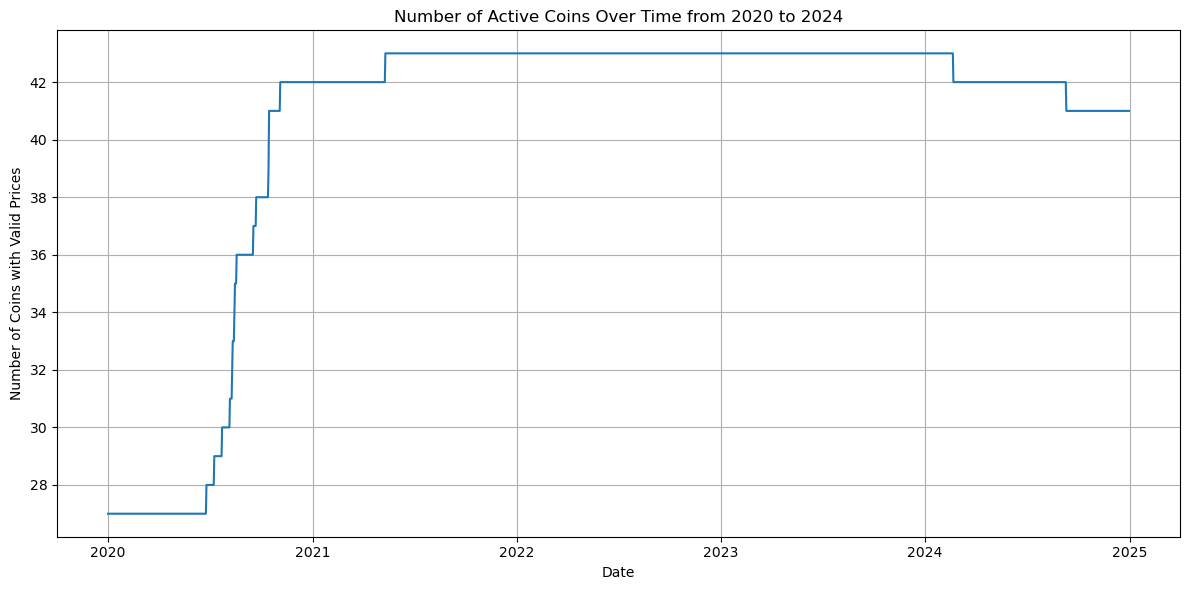

In [60]:
# Check the starting time of each coins, plot the number of active coins overtime
valid_counts = (
    data_train["close"]
    .notna()
    .groupby(level="date")
    .sum()
)

# --- 3. Plot ---
plt.figure(figsize=(12, 6))
plt.plot(valid_counts.index, valid_counts.values)

plt.title("Number of Active Coins Over Time from " + train_start_year + " to " + train_end_year)
plt.xlabel("Date")
plt.ylabel("Number of Coins with Valid Prices")

plt.grid(True)
plt.tight_layout()
plt.show()

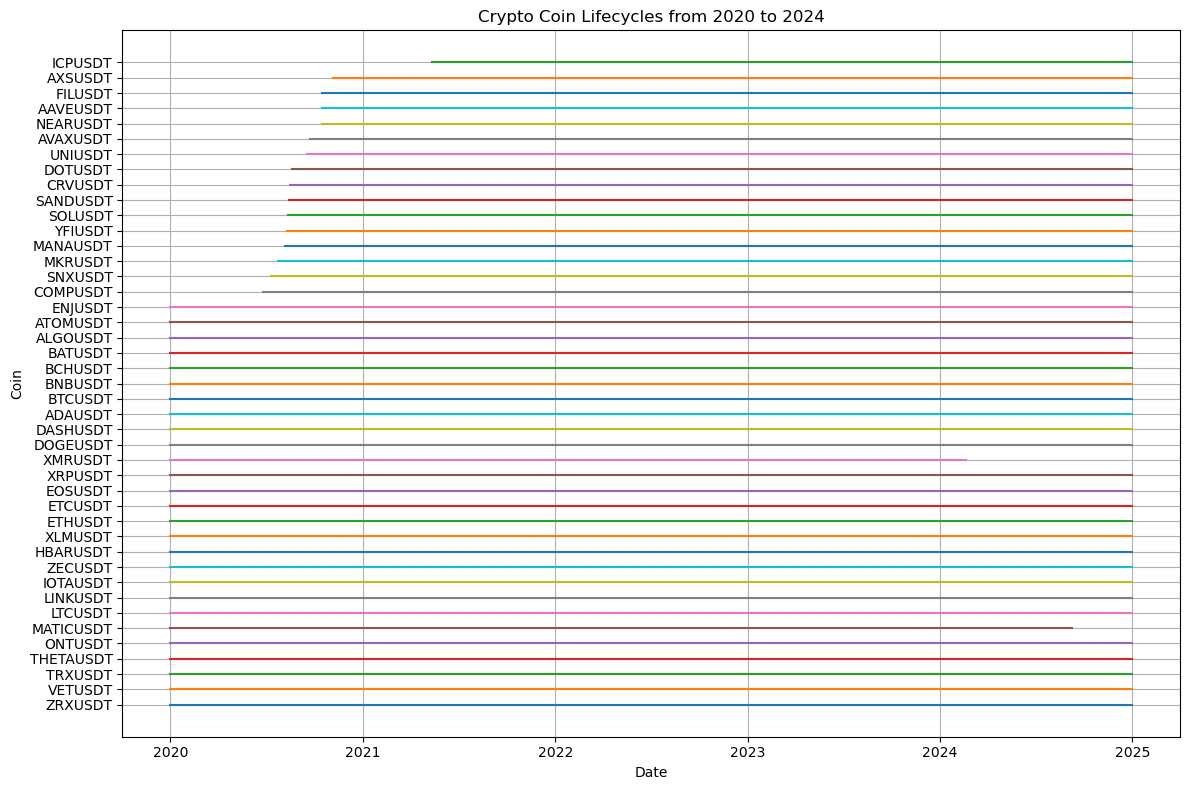

In [61]:
# Plot the lifecycle of each coin accordingly.
close = data_train["close"]

# Compute lifecycle
lifecycle = close.groupby("symbol").apply(
    lambda x: pd.Series({
        "start": x.first_valid_index()[0] if x.first_valid_index() else None,
        "end": x.last_valid_index()[0] if x.last_valid_index() else None
    })
).unstack()

# Drop coins that never had data (just in case)
lifecycle = lifecycle.dropna()
# Sort by start date (nicer visualization)
lifecycle = lifecycle.sort_values("start")

plt.figure(figsize=(12, 8))

for i, (symbol, row) in enumerate(lifecycle.iterrows()):
    plt.plot([row["start"], row["end"]], [i, i])

plt.yticks(range(len(lifecycle)), lifecycle.index)
plt.xlabel("Date")
plt.ylabel("Coin")
plt.title("Crypto Coin Lifecycles from " + train_start_year + " to " + train_end_year)

plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
# Some basic functions for alpha calculations
coin_num = len(all_symbols)
date_num = len(all_dates)
def adv(data, window):
    vol_mat = data['volume'].unstack('symbol')
    return vol_mat.rolling(window).mean()

def vwap(data):
    open_mat = data['open'].unstack('symbol')
    clo_mat = data['close'].unstack('symbol')
    high_mat = data['high'].unstack('symbol')
    low_mat = data['low'].unstack('symbol')
    # Originally, the Volume Weighted Average Price is calculated as the sum of prices * volumes / the sum of volumes
    # Here we made an approximation
    vwap_mat = (clo_mat + high_mat + low_mat) / 3
    return vwap_mat
def rollingcovariance(series1, series2, window):
    # A sliding window way to calculate the rolling covariance
    mean_x = series1.rolling(window).mean()
    mean_y = series2.rolling(window).mean()
    mean_xy = (series1 * series2).rolling(window).mean()
    return mean_xy - mean_x * mean_y

def rollingcorrelation(series1, series2, window):
    # A sliding window way to calculate the rolling correlation
    # The rolling window methods' std has default ddof = 1, we need to manually send them into 0
    std_x = series1.rolling(window).std(ddof = 0)
    std_y = series2.rolling(window).std(ddof = 0)
    corr = rollingcovariance(series1, series2, window) / (std_x * std_y)
    
    # Only compute correlation when both std is not 0, otherwise just go nan.
    corr[(std_x == 0) | (std_y == 0)] = np.nan
    return corr

In [63]:
def normalreturn(data):
    col_mat = data['close'].unstack('symbol')
    ret = (col_mat - col_mat.shift(1))/col_mat.shift(1)
    return ret.T.values

ret_train = normalreturn(data_train)
ret_test = normalreturn(data_test)

In [64]:
def IC(alpha, ret, k = 1):
    output = np.full(np.shape(alpha)[-1]-k, np.nan)
    for i in range(len(output)):
        alpha_i = alpha[:, i]
        ret_i = ret[:, i+k]
        
        # keep only valid pairs
        mask = ~np.isnan(alpha_i) & ~np.isnan(ret_i)
        
        x = alpha_i[mask]
        y = ret_i[mask]
        # need at least 2 points for correlation
        if len(x) > 1 and np.std(x) != 0 and np.std(y) != 0:
            output[i] = np.corrcoef(x, y)[0, 1]
    
    return output

In [65]:
def summaryic(ic_list):
    valid_value = []
    for j in ic_list:
        if ~np.isnan(j):
            valid_value.append(j)
    valid_value = np.array(valid_value)
    output = []
    m = np.mean(valid_value)
    n = np.std(valid_value)
    t = m * np.sqrt(len(valid_value)) / n
    return [m, n, t]

In [66]:
# Initialize the alpha dictionary for training and testing data, whose key is the number
alpha_train = {}
alpha_test = {}

In [67]:
# Alpha#101: ((close - open) / ((high - low) + .001)) 
#def alpha101(data):
#    col_mat = data['close'].unstack('symbol')
#    open_mat = data['open'].unstack('symbol')
#    high_mat = data['high'].unstack('symbol')
#    low_mat = data['low'].unstack('symbol')
#    return ((col_mat - open_mat)/ (high_mat -low_mat + 0.001)).T.values
# alpha[101] = alpha101(data_train)

In [68]:
# Alpha#1: (rank(Ts_ArgMax(SignedPower(((returns < 0) ? stddev(returns, 20) : close), 2.), 5)) -0.5) 
def alpha1(data):
    col_mat = data['close'].unstack('symbol')
    ret = (col_mat - col_mat.shift(1))/col_mat.shift(1)
    std20 = ret.rolling(20).std(ddof=0)
    expr = std20.where(ret < 0, col_mat)
    expr = np.sign(expr) * expr * expr
    argmax = expr.rolling(5).apply(lambda x: len(x) - 1 - np.argmax(x), raw=True)
    rank = argmax.rank(axis = 1, pct = True)
    rank1 = rank.reindex(columns = data.index.get_level_values("symbol").unique()) - 0.5
    return rank1.T.values

alpha_train[1] = alpha1(data_train)
alpha_test[1] = alpha1(data_test)
    

In [69]:
# Alpha#2: (-1 * correlation(rank(delta(log(volume), 2)), rank(((close - open) / open)), 6)) 
def alpha2(data):
    vol_mat = data['volume'].unstack('symbol')
    log_vol = np.log(vol_mat)
    delta_log_volume = log_vol - log_vol.shift(2)
    rank1 = delta_log_volume.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    
    col_mat = data['close'].unstack('symbol')
    open_mat = data['open'].unstack('symbol')
    delta_price = (col_mat - open_mat)/open_mat
    rank2 = delta_price.rank(axis = 1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = -rollingcorrelation(rank1, rank2, 6)

    return alpha.T.values
alpha_train[2] = alpha2(data_train)   
alpha_test[2] = alpha2(data_test)

In [70]:
# Alpha#3: (-1 * correlation(rank(open), rank(volume), 10)) 
def alpha3(data):
    open_mat = data['open'].unstack('symbol')
    rank_mat = open_mat.rank(axis=1, pct=True)
    rank_mat = rank_mat.reindex(columns=data.index.get_level_values("symbol").unique())

    vol_mat = data['volume'].unstack('symbol')
    vrank_mat = vol_mat.rank(axis=1, pct=True)
    vrank_mat = vrank_mat.reindex(columns=data.index.get_level_values("symbol").unique())

    alpha = -rollingcorrelation(rank_mat, vrank_mat, 10)

    return alpha.T.values
alpha_train[3] = alpha3(data_train)
alpha_test[3] = alpha3(data_test)

In [71]:
# Alpha#5: (rank((open - (sum(vwap, 10) / 10))) * (-1 * abs(rank((close - vwap))))) 
def alpha5(data):
    open_mat = data['open'].unstack('symbol')
    clo_mat = data['close'].unstack('symbol')
    vwap_mat = vwap(data)

    sum_vwap_10 = vwap_mat.rolling(10).mean()
    diff = open_mat - sum_vwap_10
    rank1 = diff.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    diff2 = clo_mat - vwap_mat
    rank2 = diff2.rank(axis = 1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = - rank1 * abs(rank2)
    return alpha.T.values
alpha_train[5] = alpha5(data_train)
alpha_test[5] = alpha5(data_test)

In [72]:
# Alpha#6: (-1 * correlation(open, volume, 10)) 
def alpha6(data):
    open_mat = data['open'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    alpha = -rollingcorrelation(open_mat, vol_mat, 10)
    return alpha.T.values

alpha_train[6] = alpha6(data_train)
alpha_test[6] = alpha6(data_test)
    

In [73]:
# Alpha#9: ((0 < ts_min(delta(close, 1), 5)) ? delta(close, 1) : ((ts_max(delta(close, 1), 5) < 0) ?delta(close, 1) : (-1 * delta(close, 1)))) 
def alpha9(data):
    clo_mat = data['close'].unstack('symbol')
    delta = clo_mat - clo_mat.shift(1)
    tsmin = delta.rolling(5).min()
    tsmax = delta.rolling(5).max()
    inn = delta.where(tsmax < 0, -1 * delta)
    alpha = delta.where(tsmin > 0, inn)
    return alpha.T.values
alpha_train[9] = alpha9(data_train)
alpha_test[9] = alpha9(data_test)

In [74]:
# Alpha#10: rank(((0 < ts_min(delta(close, 1), 4)) ? delta(close, 1) : ((ts_max(delta(close, 1), 4) < 0)? delta(close, 1) : (-1 * delta(close, 1)))))
def alpha10(data):
    clo_mat = data['close'].unstack('symbol')
    delta = clo_mat - clo_mat.shift(1)
    tsmin = delta.rolling(4).min()
    tsmax = delta.rolling(4).max()
    inn = delta.where(tsmax < 0, -1 * delta)
    alpha = delta.where(tsmin > 0, inn)
    alpha = alpha.rank(axis=1, pct=True)
    return alpha.T.values
alpha_train[10] = alpha10(data_train)
alpha_test[10] = alpha10(data_test) 

In [75]:
# Alpha#11: ((rank(ts_max((vwap - close), 3)) + rank(ts_min((vwap - close), 3))) *rank(delta(volume, 3))) 
def alpha11(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    vwap_mat = vwap(data)

    diff1 = vwap_mat - clo_mat
    tsmax = diff1.rolling(3).max()
    rank1 = tsmax.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    tsmin = diff1.rolling(3).min()
    rank2 = tsmin.rank(axis=1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())

    delta = vol_mat - vol_mat.shift(3)
    rank3 = delta.rank(axis = 1, pct = True)
    rank3 = rank3.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = (rank1 + rank2) * rank3
    return alpha.T.values
alpha_train[11] = alpha11(data_train)
alpha_test[11] = alpha11(data_test)

In [76]:
# Alpha#12: (sign(delta(volume, 1)) * (-1 * delta(close, 1))) 
def alpha12(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    alpha = np.sign(vol_mat - vol_mat.shift(1)) * (-1) * (clo_mat - clo_mat.shift(1))
    return alpha.T.values
alpha_train[12] = alpha12(data_train)
alpha_test[12] = alpha12(data_test)

In [77]:
# Alpha#13: (-1 * rank(covariance(rank(close), rank(volume), 5))) 
def alpha13(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    rank1 = clo_mat.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    rank2 = vol_mat.rank(axis = 1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())
    cov = rollingcovariance(rank1, rank2, 5)
    rank3 = cov.rank(axis = 1, pct = True)
    rank3 = rank3.reindex(columns = data.index.get_level_values("symbol").unique())
    alpha = -rank3
    return alpha.T.values
alpha_train[13] = alpha13(data_train)
alpha_test[13] = alpha13(data_test)

In [78]:
# Alpha#14: ((-1 * rank(delta(returns, 3))) * correlation(open, volume, 10)) 
def alpha14(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    corr = rollingcorrelation(clo_mat, vol_mat, 10)
    ret = (clo_mat - clo_mat.shift(1))/clo_mat.shift(1)
    delta = ret - ret.shift(3)
    rank = delta.rank(axis = 1, pct = True)
    rank = rank.reindex(columns = data.index.get_level_values("symbol").unique())
    alpha = -rank* corr
    return alpha.T.values

alpha_train[14] = alpha14(data_train)
alpha_test[14] = alpha14(data_test)

In [79]:
# Alpha#18: (-1 * rank(((stddev(abs((close - open)), 5) + (close - open)) + correlation(close, open,10))))
def alpha18(data):
    clo_mat = data['close'].unstack('symbol')
    open_mat = data['open'].unstack('symbol')
    diff = (clo_mat - open_mat)
    abs_diff = abs(diff)
    stddev = abs_diff.rolling(5).std(ddof = 0)
    corr = rollingcorrelation(clo_mat, open_mat, 10)
    ind = corr + stddev + clo_mat - open_mat
    
    rank = ind.rank(axis = 1, pct = True)
    rank = rank.reindex(columns = data.index.get_level_values("symbol").unique())
    alpha = -rank
    return alpha.T.values
alpha_train[18] = alpha18(data_train)
alpha_test[18] = alpha18(data_test)  

In [80]:
# Alpha#20: (((-1 * rank((open - delay(high, 1)))) * rank((open - delay(close, 1)))) * rank((open -delay(low, 1)))) 
def alpha20(data):
    open_mat = data['open'].unstack('symbol')
    high_mat = data['high'].unstack('symbol')
    low_mat = data['low'].unstack('symbol')
    clo_mat = data['close'].unstack('symbol')

    ind1 = open_mat - high_mat.shift(1)
    rank1 = ind1.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    ind2 = open_mat - clo_mat.shift(1)
    rank2 = ind2.rank(axis = 1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())

    ind3 = open_mat - low_mat.shift(1)
    rank3 = ind3.rank(axis = 1, pct = True)
    rank3 = rank3.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = - rank1 * rank2 * rank3
    return alpha.T.values
alpha_train[20] = alpha20(data_train)
alpha_test[20] = alpha20(data_test)

In [81]:
# Alpha#22: (-1 * (delta(correlation(high, volume, 5), 5) * rank(stddev(close, 20))))
def alpha22(data):
    high_mat = data['high'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    clo_mat = data['close'].unstack('symbol')

    corr = rollingcorrelation(high_mat, vol_mat, 5)
    delta = corr - corr.shift(5)
    
    stddev = clo_mat.rolling(20).std(ddof = 0)
    rank = stddev.rank(axis = 1, pct = True)
    rank = rank.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = - delta * rank
    return alpha.T.values
alpha_train[22] = alpha22(data_train)
alpha_test[22] = alpha22(data_test)

In [82]:
# Alpha#25: rank(((((-1 * returns) * adv20) * vwap) * (high - close)))
def alpha25(data):
    clo_mat = data['close'].unstack('symbol')
    ret = (clo_mat - clo_mat.shift(1))/clo_mat.shift(1)
    adv20 = adv(data, 20)
    vwap_mat = vwap(data)

    high_mat = data['high'].unstack('symbol')
    ind = -1 * ret * adv20 * vwap_mat * (high_mat - clo_mat)
    rank = ind.rank(axis = 1, pct = True)
    alpha = rank.reindex(columns = data.index.get_level_values("symbol").unique())
    return alpha.T.values

alpha_train[25] = alpha25(data_train)
alpha_test[25] = alpha25(data_test)

In [83]:
# Alpha#30: (((1.0 - rank(((sign((close - delay(close, 1))) + sign((delay(close, 1) - delay(close, 2)))) + sign((delay(close, 2) - delay(close, 3)))))) * sum(volume, 5)) / sum(volume, 20))
def alpha30(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    sign1 = np.sign(clo_mat - clo_mat.shift(1))
    sign2 = np.sign(clo_mat.shift(1) - clo_mat.shift(2))
    sign3 = np.sign(clo_mat.shift(2) - clo_mat.shift(3))
    ind = sign1 + sign2 + sign3
    rank1 = ind.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    sum1 = vol_mat.rolling(5).sum()
    sum2 = vol_mat.rolling(20).sum()
    alpha = (1-rank1)  * sum1 / sum2
    return alpha.T.values

alpha_train[30] = alpha30(data_train)
alpha_test[30] = alpha30(data_test)

In [84]:
# Alpha#40: ((-1 * rank(stddev(high, 10))) * correlation(high, volume, 10))
def alpha40(data):
    high_mat = data['high'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')

    stddev = high_mat.rolling(10).std(ddof = 0)
    rank1 = stddev.rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    corr = rollingcorrelation(high_mat, vol_mat, 10)
    alpha = - rank1 * corr
    return alpha.T.values

alpha_train[40] = alpha40(data_train)
alpha_test[40] = alpha40(data_test)

In [85]:
# Alpha#41: (((high * low)^0.5) - vwap)
def alpha41(data):
    high_mat = data['high'].unstack('symbol')
    low_mat = data['low'].unstack('symbol')
    vw = vwap(data)
    alpha = (high_mat * low_mat)**0.5 - vw

    return alpha.T.values

alpha_train[41] = alpha41(data_train)
alpha_test[41] = alpha41(data_test)

In [86]:
# Alpha#42: (rank((vwap - close)) / rank((vwap + close)))
def alpha42(data):
    clo_mat = data['close'].unstack('symbol')
    vw = vwap(data)

    rank1 = (vw - clo_mat).rank(axis = 1, pct = True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    rank2 = (vw + clo_mat).rank(axis = 1, pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())
    alpha = rank1/rank2

    return alpha.T.values
alpha_train[42] = alpha42(data_train)
alpha_test[42] = alpha42(data_test)

In [87]:
# Alpha#43: (ts_rank((volume / adv20), 20) * ts_rank((-1 * delta(close, 7)), 8)) 
def alpha43(data):
    clo_mat = data['close'].unstack('symbol')
    vol_mat = data['volume'].unstack('symbol')
    adv20 = adv(data, 20)

    ind = vol_mat / adv20
    rank1 = ind.rolling(20).rank(pct=True)
    rank1 = rank1.reindex(columns = data.index.get_level_values("symbol").unique())

    delta = -clo_mat + clo_mat.shift(7)
    rank2 = delta.rolling(8).rank(pct = True)
    rank2 = rank2.reindex(columns = data.index.get_level_values("symbol").unique())

    alpha = rank1 * rank2
    return alpha.T.values
alpha_train[43] = alpha43(data_train)
alpha_test[43] = alpha43(data_test)

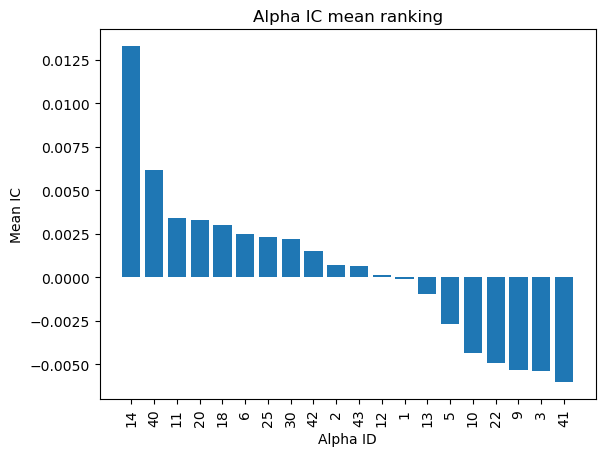

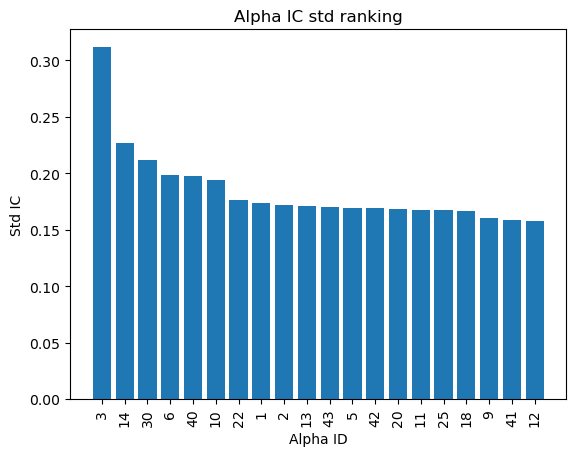

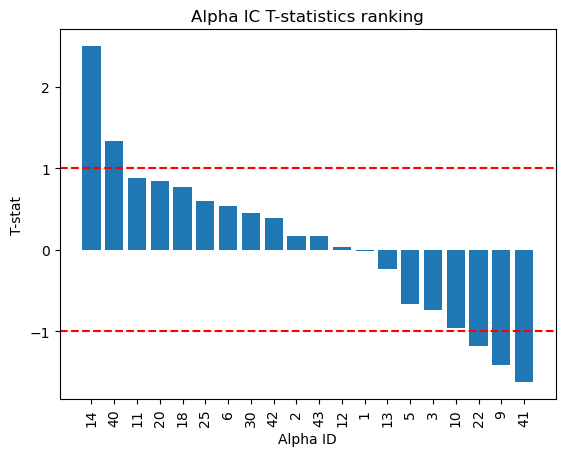

In [88]:
# A summary of each alpha's IC, including mean, standard deviation and t-statistics.
# Thumb's Rule: Choose those alpha, whose IC has an absolute value of t-statistics >= 1.
alpha_ids = []
means = []
stds = []
tstats = []

# ---------------------------
# compute IC statistics
# ---------------------------
for j in alpha_train:
    s = summaryic(IC(alpha_train[j], ret_train))
    alpha_ids.append(j)
    means.append(s[0])
    stds.append(s[1])
    tstats.append(s[2])

alpha_ids = np.array(alpha_ids)
means = np.array(means)
stds = np.array(stds)
tstats = np.array(tstats)

# Plot mean:
order_mean = np.argsort(means)[::-1]

plt.figure()
plt.bar(alpha_ids[order_mean].astype(str), means[order_mean])
plt.title("Alpha IC mean ranking")
plt.xlabel("Alpha ID")
plt.ylabel("Mean IC")
plt.xticks(rotation=90)
plt.show()

# Plot std
order_std = np.argsort(stds)[::-1]

plt.figure()
plt.bar(alpha_ids[order_std].astype(str), stds[order_std])
plt.title("Alpha IC std ranking")
plt.xlabel("Alpha ID")
plt.ylabel("Std IC")
plt.xticks(rotation=90)
plt.show()

# Plot t-stat
order_t = np.argsort(tstats)[::-1]

plt.figure()
plt.bar(alpha_ids[order_t].astype(str), tstats[order_t])
plt.title("Alpha IC T-statistics ranking")
plt.xlabel("Alpha ID")
plt.ylabel("T-stat")
plt.axhline(1, linestyle='--', color='red')
plt.axhline(-1, linestyle='--', color='red')
plt.xticks(rotation=90)
plt.show()

In [89]:
# At the first glance, one might think that alpha 14 is the only alpha that worth researching, since it has the highest t-stat (over 2).
# However, after conducting an out-of-sample test, its t-stat decays repaidly.
alpha14_train = alpha_train[14]
ic_train = IC(alpha14_train, ret_train)
print('In-Sample-t-stat of alpha 14: '+ str(summaryic(ic_train)[-1]))

alpha14_test = alpha_test[14]
ic_test = IC(alpha14_test, ret_test)
print('Out-of-Sample-t-stat of alpha 14: ' + str(summaryic(ic_test)[-1]))

# Possible reasons: ...


In-Sample-t-stat of alpha 14: 2.494509641715744
Out-of-Sample-t-stat of alpha 14: 0.44407965373218855


In [90]:
# On the other hand, there are some weak alphas that have a moderate t-stat in-sample:
# For example, alpha 40, and alpha 22, 9, 41 (after flipping). 
# We use the combination technique, combing several weak alphas to get a stronger one.
# We first check whether they are correlated:
alpha_list_ind = [14, 40, 41, 22, 9]

alpha_list_train = []
for alpha_num in alpha_list_ind:
    ic = IC(alpha_train[alpha_num], ret_train)
    if summaryic(ic)[0] > 0:
        alpha_list_train.append(alpha_train[alpha_num])
    else: # Flipping alphas
        alpha_list_train.append(-alpha_train[alpha_num])
    
def alpha_corr_matrix(alpha_list):
    n = len(alpha_list)
    corr_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            
            date_num = alpha_list[i].shape[1]
            corrs = []

            for t in range(date_num):
                x = alpha_list[i][:, t]
                y = alpha_list[j][:, t]

                mask = ~np.isnan(x) & ~np.isnan(y)

                if np.sum(mask) > 1:
                    corr = np.corrcoef(x[mask], y[mask])[0, 1]
                    corrs.append(corr)

            corr_matrix[i, j] = np.nanmean(corrs) if len(corrs) > 0 else np.nan

    return corr_matrix


print('Correlation matrix of alphas ' + str(alpha_list_ind) + ' in training data: ')
print(str(alpha_corr_matrix(alpha_list_train)))

Correlation matrix of alphas [14, 40, 41, 22, 9] in training data: 
[[ 1.          0.41752399 -0.02206143 -0.01264209 -0.02649161]
 [ 0.41752399  1.         -0.0274511   0.00958695 -0.0053281 ]
 [-0.02206143 -0.0274511   1.          0.01404985  0.64744409]
 [-0.01264209  0.00958695  0.01404985  1.          0.02049878]
 [-0.02649161 -0.0053281   0.64744409  0.02049878  1.        ]]


In [91]:
# An naive idea might be combining these alpha equally, but this is not a good idea
new_alpha_naive = (alpha_train[40] - alpha_train[41] - alpha_train[9] - alpha_train[22]) * 0.25
ic_train_naive = IC(new_alpha_naive, ret_train)
print('t-stat of equally weight combined alpha: ' + str(summaryic(ic_train_naive)[-1]))

# It could be seen that the t-static does not improve. This is because of the scalling effect. One of these alpha dominates everything.

t-stat of equally weight combined alpha: 1.4547392222693387


In [92]:
# A better idea is do a rank normalization: normalize each alpha into [-0.5, 0.5]
def rank_normalize(alpha):
    result = np.full_like(alpha, np.nan, dtype=float)
    
    for t in range(alpha.shape[1]):  # loop over time
        col = alpha[:, t]
        mask = ~np.isnan(col)
        
        if np.sum(mask) > 1:
            ranks = np.argsort(np.argsort(col[mask]))
            ranks = ranks / (len(ranks) - 1)
            result[mask, t] = ranks - 0.5
            
    return result

def equal_weight_combining(alpha, old_alpha_list, ret):
    ss = 0
    for alpha_num in old_alpha_list:
        if summaryic(IC(alpha[alpha_num], ret))[-1] < 0: # Flipping
            ss -= rank_normalize(alpha[alpha_num])
        else:
            ss += rank_normalize(alpha[alpha_num])
    return ss / len(old_alpha_list)

def ic_weight_combining(alpha, old_alpha_list, ret):
    ss = 0
    for alpha_num in old_alpha_list:
        ss += np.nanmean(IC(alpha[alpha_num], ret)) * rank_normalize(alpha[alpha_num])
    return ss

def corr_adj_weight_combining(alpha, old_alpha_list, ret, regularize=0.1):
    alpha_list = []
    ic_list = []

    # Step 1: align sign and collect IC
    for alpha_num in old_alpha_list:
        ic_series = IC(alpha[alpha_num], ret)
        ic_mean = summaryic(ic_series)[0]

        if ic_mean > 0:
            aligned_alpha = alpha[alpha_num]
        else:
            aligned_alpha = -alpha[alpha_num]

        alpha_list.append(aligned_alpha)
        ic_list.append(abs(ic_mean))  # use magnitude after flipping

    # Convert to numpy
    IC_vec = np.array(ic_list)

    # Step 2: compute correlation matrix
    Sigma = alpha_corr_matrix(alpha_list)

    # Step 3: regularization
    N = len(old_alpha_list)
    Sigma_reg = Sigma + regularize * np.eye(N)

    # Step 4: compute weights
    w = np.linalg.inv(Sigma_reg) @ IC_vec

    # Step 5: normalize weights (important)
    w = w / np.sum(np.abs(w))

    # Step 6: build combined signal
    combined_signal = 0
    for i in range(N):
        combined_signal += w[i] * rank_normalize(alpha_list[i])

    return combined_signal

In [93]:
alpha_list_ind = [14, 40, 41,22, 9]
super_alphas_ic_train = {}
super_alphas_ic_test = {}

for num in alpha_list_ind:
    super_alphas_ic_train['alpha' + str(num)] = IC(alpha_train[num], ret_train)
    super_alphas_ic_test['alpha' + str(num)] = IC(alpha_test[num], ret_test)

# Equal weight combining 
new_alpha_train = equal_weight_combining(alpha_train, alpha_list_ind, ret_train)
new_alpha_test = equal_weight_combining(alpha_test, alpha_list_ind, ret_test)
super_alphas_ic_train['Equally weighted'] = IC(new_alpha_train, ret_train)
super_alphas_ic_test['Equally weighted'] = IC(new_alpha_test, ret_test)

# IC-weighted combining
new_alpha_train_ic = ic_weight_combining(alpha_train, alpha_list_ind, ret_train)
new_alpha_test_ic = ic_weight_combining(alpha_test, alpha_list_ind, ret_test)
super_alphas_ic_train['IC weighted'] = IC(new_alpha_train_ic, ret_train)
super_alphas_ic_test['IC weighted'] = IC(new_alpha_test_ic, ret_test)


# Correlated-weighted combining
new_alpha_train_corr = corr_adj_weight_combining(alpha_train, alpha_list_ind, ret_train, 0.1)
new_alpha_test_corr = corr_adj_weight_combining(alpha_test, alpha_list_ind, ret_test, 0.1)
super_alphas_ic_train['Correlation weighted'] = IC(new_alpha_train_corr, ret_train)
super_alphas_ic_test['Correlation weighted'] = IC(new_alpha_test_corr, ret_test)

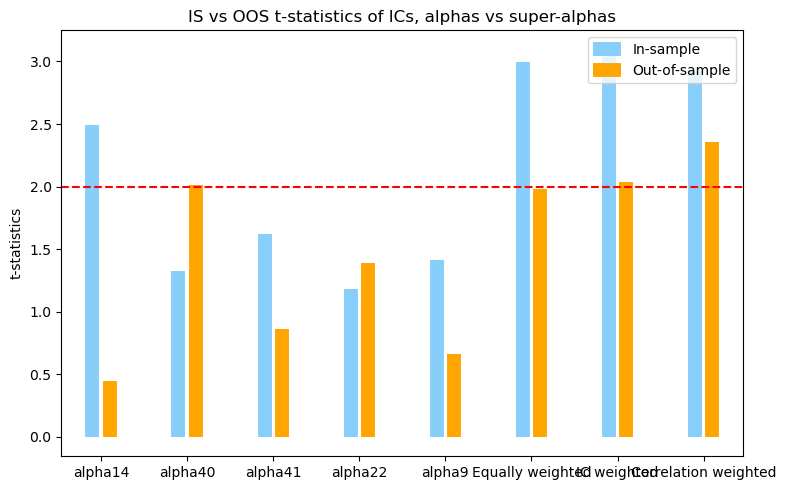

In [94]:
super_alphas_ic_tstats = {}

for method in super_alphas_ic_train:
    super_alphas_ic_tstats[method] = (np.abs(summaryic(super_alphas_ic_train[method])[-1]), np.abs(summaryic(super_alphas_ic_test[method])[-1]))

methods = list(super_alphas_ic_tstats.keys())
is_values = [v[0] for v in super_alphas_ic_tstats.values()]
oos_values = [v[1] for v in super_alphas_ic_tstats.values()]

# Positions
x = np.arange(len(methods))
offset = 0.1  # controls spacing within each method

plt.figure(figsize=(8, 5))

# Plot vertical lines
for i in range(len(methods)):
    plt.vlines(x[i] - offset, 0, is_values[i], linewidth=10, color = 'lightskyblue', label='In-sample' if i == 0 else "")
    plt.vlines(x[i] + offset, 0, oos_values[i], linewidth=10, color = 'orange', label='Out-of-sample' if i == 0 else "")
plt.axhline(2, linestyle='--', color='red')
# Formatting
plt.xticks(x, methods)
plt.ylabel('t-statistics')
plt.title('IS vs OOS t-statistics of ICs, alphas vs super-alphas')
plt.legend()

plt.tight_layout()
plt.show()

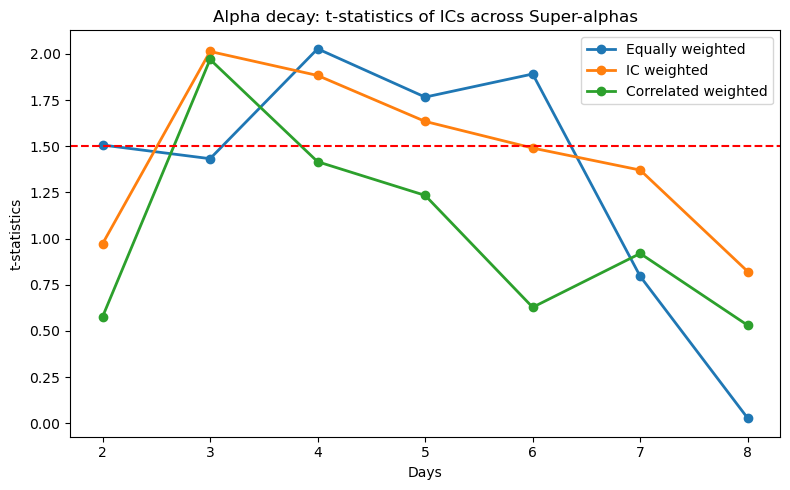

In [95]:
ic_curve = {'Equally weighted' : [super_alphas_ic_train['Equally weighted'][0]], 'IC weighted': [super_alphas_ic_train['IC weighted'][0]],
           'Correlated weighted': [super_alphas_ic_train['Correlation weighted'][0]]}
for days in range(2,9):
    ic_curve['Equally weighted'].append(summaryic(IC(new_alpha_train, ret_train, days))[-1])
    ic_curve['IC weighted'].append(summaryic(IC(new_alpha_train_ic, ret_train,days))[-1])
    ic_curve['Correlated weighted'].append(summaryic(IC(new_alpha_train_corr, ret_train,days))[-1])


# X-axis (e.g., periods or horizons)
x = np.arange(len(next(iter(ic_curve.values())))) +1

plt.figure(figsize=(8, 5))

# Plot each method as a line
for label, values in ic_curve.items():
    plt.plot(x, values, marker='o', linewidth=2, label=label)

# Formatting
plt.xlabel('Days')
plt.ylabel('t-statistics')
plt.title('Alpha decay: t-statistics of ICs across Super-alphas')
plt.legend()
plt.axhline(1.5, linestyle='--', color='red')

plt.tight_layout()
plt.show()

In [96]:
# The summary statistics look promising. Some other facts about this alpha in the training data:
# Positive ratio:
pos_ratio = np.mean(ic_train > 0)
print('positive ratio: ' + str(pos_ratio))
# No so high, but acceptable

# average rolling ic of window 60 days (2month), to see whether it decays nearly:
rolling_ic = pd.Series(ic_train).rolling(60).mean()
print('Fraction of time the 60-day average IC is positive : ' + str(np.mean(rolling_ic > 0)))
# Very well

def turnover_timeseries(alpha):
    rank = pd.DataFrame(alpha).rank(axis=0, pct=True)

    turnover_series = [np.nan for j in range(rank.shape[1] - 1)]

    for t in range(rank.shape[1] - 1):
        diff = np.array(rank.iloc[:, t]) - np.array(rank.iloc[:, t+1])
        if not np.all(np.isnan(diff)):
            turnover_t = np.nanmean(np.abs(diff))
            turnover_series[t] = turnover_t

    return np.array(turnover_series)

# Very well

positive ratio: 0.523001095290252
Fraction of time the 60-day average IC is positive : 0.664841182913472


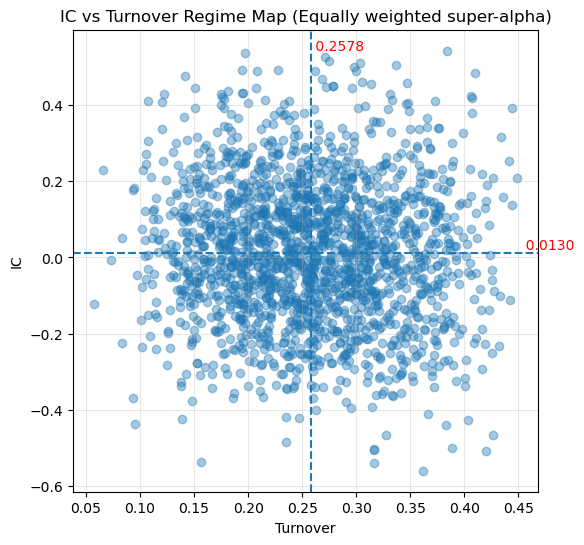

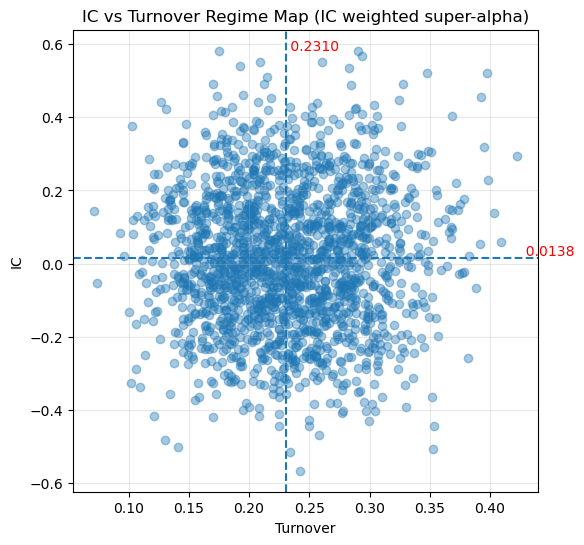

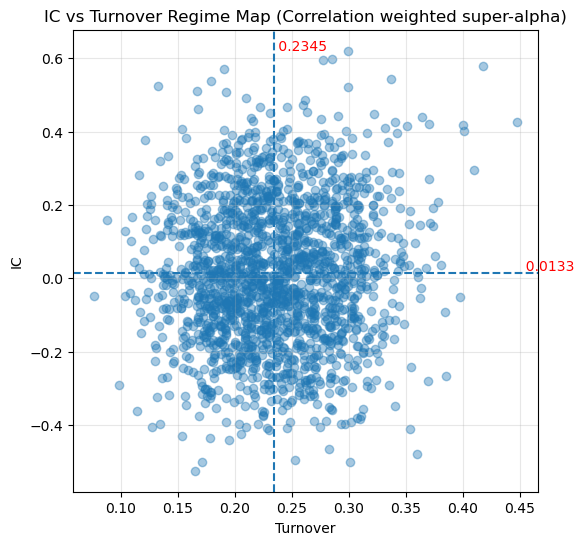

In [97]:
ic_turnover_plot = {}

ic_turnover_plot['Equally weighted'] = (super_alphas_ic_train['Equally weighted'], turnover_timeseries(new_alpha_train))
ic_turnover_plot['IC weighted'] = (super_alphas_ic_train['IC weighted'], turnover_timeseries(new_alpha_train_ic))
ic_turnover_plot['Correlation weighted'] = (super_alphas_ic_train['Correlation weighted'], turnover_timeseries(new_alpha_train_corr))

for method in ic_turnover_plot:
    plt.figure(figsize=(6,6))
    ic = ic_turnover_plot[method][0]
    to = ic_turnover_plot[method][1]
    mean_ic = np.nanmean(ic)
    mean_to = np.nanmean(to)
    plt.scatter(to, ic, alpha=0.4)
    plt.axhline(mean_ic, linestyle='--')
    plt.axvline(mean_to, linestyle='--')    
    plt.text(
        np.nanmax(to),
        mean_ic,
        f"  {mean_ic:.4f}",
        va='bottom',
        color = 'red')

    plt.text(
        mean_to,
        np.nanmax(ic),
        f" {mean_to:.4f}",
        ha='left',
        color = 'red')
    plt.xlabel("Turnover")
    plt.ylabel("IC")
    plt.title(f"IC vs Turnover Regime Map ({method} super-alpha)")

    plt.grid(alpha=0.3)
    plt.show()

In [98]:
def portfolio_return_with_cost(data, alpha, percentage = 0.1, short = False, cost = 0.001):
    all_dates = data.index.get_level_values("date").unique()
    open_mat = data['open'].unstack('symbol').T.values
    close_mat = data['close'].unstack('symbol').T.values
    l = np.shape(open_mat)[1]
    daily_return = [0 for j in range(l)]

    prev_long = set()
    prev_short = set()

    for date in range(len(all_dates)-1):
        today_alpha = alpha[:, date]
        valid_count = np.sum(~np.isnan(today_alpha))

        if valid_count >= 10:
            choose_num = int(valid_count * percentage)

            valid_idx = np.where(~np.isnan(today_alpha))[0]
            sorted_idx = valid_idx[np.argsort(today_alpha[valid_idx])]

            indices_long = set(sorted_idx[-choose_num:])
            indices_short = set(sorted_idx[:choose_num])

            tmr_open = open_mat[:, date +1]
            tmr_close = close_mat[:, date +1]

            ss = 0

            for j in indices_long:
                if ~np.isnan(tmr_open[j]) and tmr_open[j] > 0:
                    ss += (tmr_close[j] - tmr_open[j])/tmr_open[j] * 1/choose_num

            if short:
                for j in indices_short:
                    if ~np.isnan(tmr_open[j]) and tmr_open[j] > 0:
                        ss += -(tmr_close[j] - tmr_open[j])/tmr_open[j] * 1/choose_num

            # --------- NEW: transaction cost ----------
            turnover_long = len(indices_long.symmetric_difference(prev_long)) / max(choose_num, 1)

            if short:
                turnover_short = len(indices_short.symmetric_difference(prev_short)) / max(choose_num, 1)
                turnover = 0.5 * (turnover_long + turnover_short)
            else:
                turnover = turnover_long

            ss -= cost * turnover
            # -----------------------------------------

            prev_long = indices_long
            prev_short = indices_short

            daily_return[date + 1] = ss

    return np.array(daily_return)

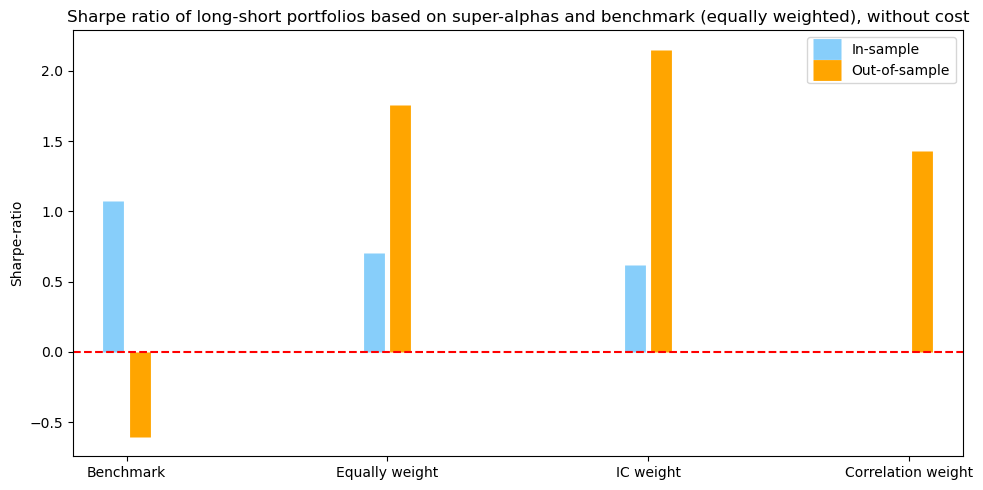

In [99]:
def sharpe_ratio(timeseries, days = 365):
    return np.mean(timeseries)/np.std(timeseries) * np.sqrt(days)


super_alphas_train = [new_alpha_train, new_alpha_train_ic, new_alpha_train_corr]
super_alphas_test = [new_alpha_test, new_alpha_test_ic, new_alpha_test_corr]
methods = ['Equally weight', 'IC weight', 'Correlation weight']

pl_super_alphas_train = []
pl_super_alphas_test = []
for i in range(len(super_alphas_train)):
    pl_super_alphas_train.append(portfolio_return_with_cost(data_train, super_alphas_train[i], 0.1, short = True, cost = 0))
    pl_super_alphas_test.append(portfolio_return_with_cost(data_test, super_alphas_test[i], 0.1, short = True, cost = 0))
    
benchmark_train = portfolio_return_with_cost(data_train, new_alpha_train, 1, short = False, cost = 0)
benchmark_test = portfolio_return_with_cost(data_test, new_alpha_test, 1, short = False, cost = 0)
sharpe_ratio_no_cost = {'Benchmark': (sharpe_ratio(benchmark_train), sharpe_ratio(benchmark_test))}

for i in range(len(super_alphas_train)):
    sharpe_ratio_no_cost[methods[i]] = (sharpe_ratio(pl_super_alphas_train[i]), sharpe_ratio(pl_super_alphas_test[i]))

is_values = [v[0] for v in sharpe_ratio_no_cost.values()]
oos_values = [v[1] for v in sharpe_ratio_no_cost.values()]
# Positions
x = np.arange(len(sharpe_ratio_no_cost))
offset = 0.05  # controls spacing within each method

plt.figure(figsize=(10, 5))

# Plot vertical lines
for i in range(len(methods) +1):
    plt.vlines(x[i] - offset, 0, is_values[i], linewidth=15, color = 'lightskyblue', label='In-sample' if i == 0 else "")
    plt.vlines(x[i] + offset, 0, oos_values[i], linewidth=15, color = 'orange', label='Out-of-sample' if i == 0 else "")
plt.axhline(0, linestyle='--', color='red')
# Formatting
plt.xticks(x, ['Benchmark'] + methods)
plt.ylabel('Sharpe-ratio')
plt.title('Sharpe ratio of long-short portfolios based on super-alphas and benchmark (equally weighted), without cost')
plt.legend()

plt.tight_layout()
plt.show()

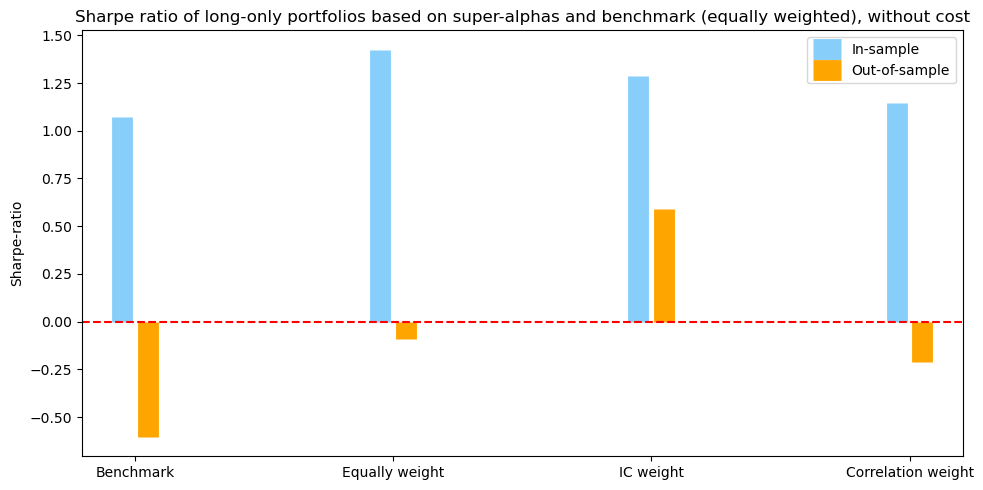

In [100]:
pl_super_alphas_train = []
pl_super_alphas_test = []
for i in range(len(super_alphas_train)):
    pl_super_alphas_train.append(portfolio_return_with_cost(data_train, super_alphas_train[i], 0.1, short = False, cost = 0))
    pl_super_alphas_test.append(portfolio_return_with_cost(data_test, super_alphas_test[i], 0.1, short = False, cost = 0))
    
benchmark_train = portfolio_return_with_cost(data_train, new_alpha_train, 1, short = False, cost = 0)
benchmark_test = portfolio_return_with_cost(data_test, new_alpha_test, 1, short = False, cost = 0)
sharpe_ratio_no_cost = {'Benchmark': (sharpe_ratio(benchmark_train), sharpe_ratio(benchmark_test))}

for i in range(len(super_alphas_train)):
    sharpe_ratio_no_cost[methods[i]] = (sharpe_ratio(pl_super_alphas_train[i]), sharpe_ratio(pl_super_alphas_test[i]))

is_values = [v[0] for v in sharpe_ratio_no_cost.values()]
oos_values = [v[1] for v in sharpe_ratio_no_cost.values()]
# Positions
x = np.arange(len(sharpe_ratio_no_cost))
offset = 0.05  # controls spacing within each method

plt.figure(figsize=(10, 5))

# Plot vertical lines
for i in range(len(methods) +1):
    plt.vlines(x[i] - offset, 0, is_values[i], linewidth=15, color = 'lightskyblue', label='In-sample' if i == 0 else "")
    plt.vlines(x[i] + offset, 0, oos_values[i], linewidth=15, color = 'orange', label='Out-of-sample' if i == 0 else "")
plt.axhline(0, linestyle='--', color='red')
# Formatting
plt.xticks(x, ['Benchmark'] + methods)
plt.ylabel('Sharpe-ratio')
plt.title('Sharpe ratio of long-only portfolios based on super-alphas and benchmark (equally weighted), without cost')
plt.legend()

plt.tight_layout()
plt.show()

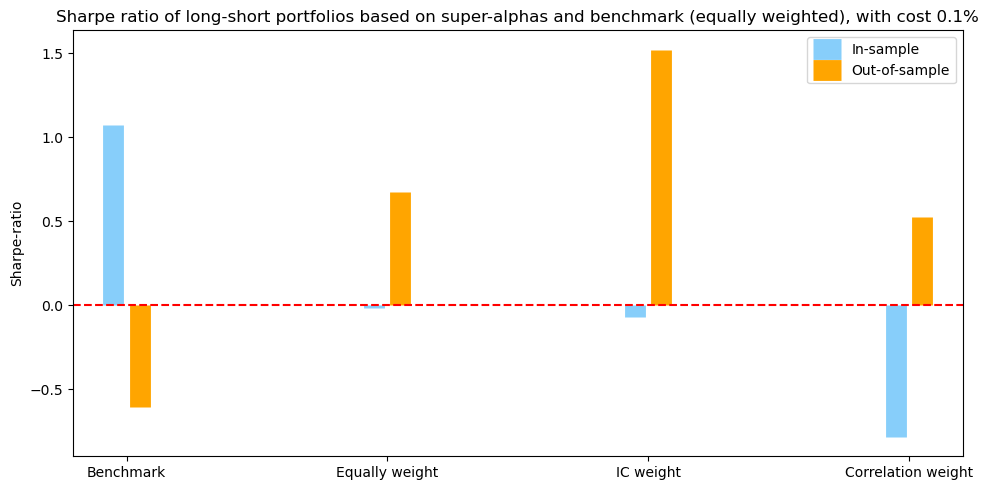

In [101]:
pl_super_alphas_train = []
pl_super_alphas_test = []
for i in range(len(super_alphas_train)):
    pl_super_alphas_train.append(portfolio_return_with_cost(data_train, super_alphas_train[i], 0.1, short = True, cost = 0.001))
    pl_super_alphas_test.append(portfolio_return_with_cost(data_test, super_alphas_test[i], 0.1, short = True, cost = 0.001))
    
benchmark_train = portfolio_return_with_cost(data_train, new_alpha_train, 1, short = False, cost = 0.001)
benchmark_test = portfolio_return_with_cost(data_test, new_alpha_test, 1, short = False, cost = 0.001)
sharpe_ratio_with_cost = {'Benchmark': (sharpe_ratio(benchmark_train), sharpe_ratio(benchmark_test))}

for i in range(len(super_alphas_train)):
    sharpe_ratio_with_cost[methods[i]] = (sharpe_ratio(pl_super_alphas_train[i]), sharpe_ratio(pl_super_alphas_test[i]))

is_values = [v[0] for v in sharpe_ratio_with_cost.values()]
oos_values = [v[1] for v in sharpe_ratio_with_cost.values()]
# Positions
x = np.arange(len(sharpe_ratio_with_cost))
offset = 0.05  # controls spacing within each method

plt.figure(figsize=(10, 5))

# Plot vertical lines
for i in range(len(methods) +1):
    plt.vlines(x[i] - offset, 0, is_values[i], linewidth=15, color = 'lightskyblue', label='In-sample' if i == 0 else "")
    plt.vlines(x[i] + offset, 0, oos_values[i], linewidth=15, color = 'orange', label='Out-of-sample' if i == 0 else "")
plt.axhline(0, linestyle='--', color='red')
# Formatting
plt.xticks(x, ['Benchmark'] + methods)
plt.ylabel('Sharpe-ratio')
plt.title('Sharpe ratio of long-short portfolios based on super-alphas and benchmark (equally weighted), with cost 0.1%')
plt.legend()

plt.tight_layout()
plt.show()

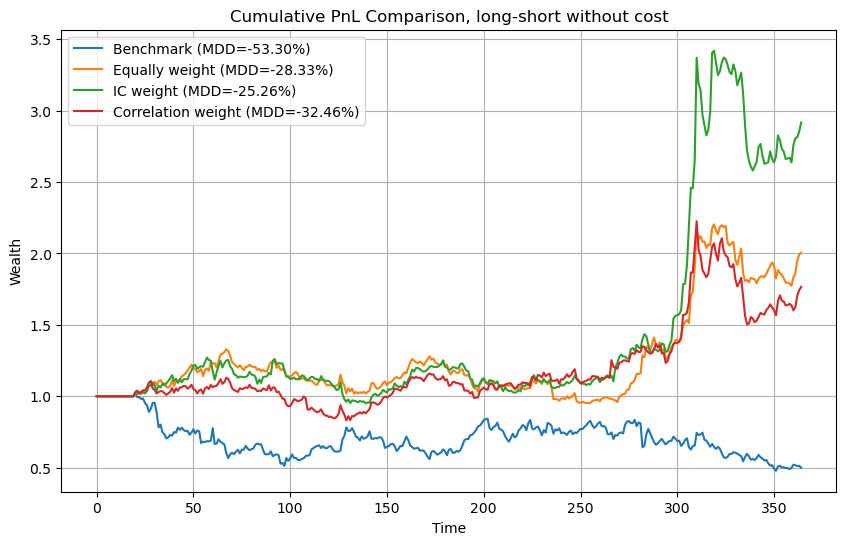

In [102]:
def cumulative_pnl(daily_return, initial_capital=1.0):
    wealth = np.zeros_like(daily_return)
    wealth[0] = initial_capital

    for t in range(1, len(daily_return)):
        wealth[t] = wealth[t-1] * (1 + daily_return[t])

    return wealth


def max_drawdown(curve):
    curve = np.array(curve)
    peak = np.maximum.accumulate(curve)
    drawdown = (curve - peak) / peak
    return np.min(drawdown), drawdown  # return both MDD and full series

pnl_curve = {}
mdd_dict = {}
dd_curve_dict = {}

# Benchmark
pnl_curve['Benchmark'] = cumulative_pnl(
    portfolio_return_with_cost(data_test, new_alpha_test, 1, short=False, cost=0)
)

mdd, dd = max_drawdown(pnl_curve['Benchmark'])
mdd_dict['Benchmark'] = mdd
dd_curve_dict['Benchmark'] = dd

# Other strategies
for i in range(len(methods)):
    name = methods[i]
    pnl_curve[name] = cumulative_pnl(
        portfolio_return_with_cost(data_test, super_alphas_test[i], 0.1, short=True, cost=0)
    )
    
    mdd, dd = max_drawdown(pnl_curve[name])
    mdd_dict[name] = mdd
    dd_curve_dict[name] = dd

# --------- Plot PnL ----------
plt.figure(figsize=(10, 6))

for name, curve in pnl_curve.items():
    plt.plot(curve, label=f"{name} (MDD={mdd_dict[name]:.2%})")

plt.title("Cumulative PnL Comparison, long-short without cost")
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.show()


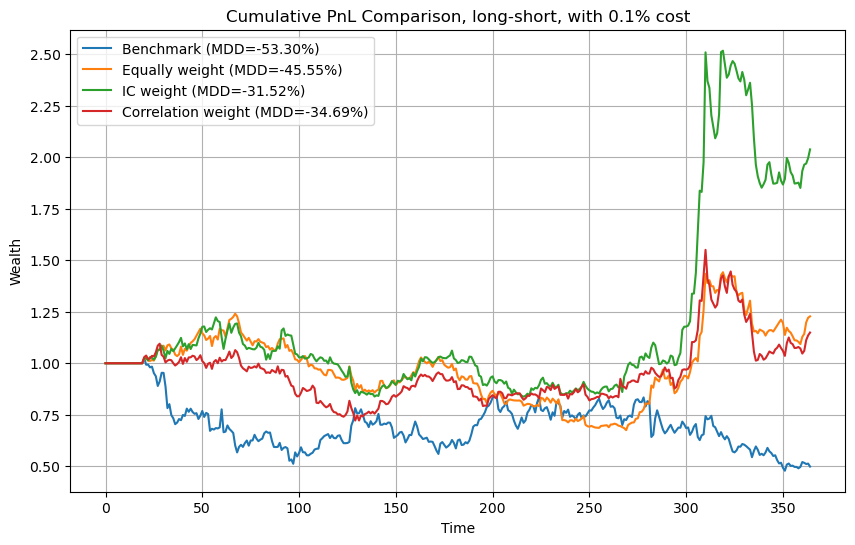

In [103]:
pnl_curve = {}
mdd_dict = {}
dd_curve_dict = {}

# Benchmark
pnl_curve['Benchmark'] = cumulative_pnl(
    portfolio_return_with_cost(data_test, new_alpha_test, 1, short=False, cost=0.001)
)

mdd, dd = max_drawdown(pnl_curve['Benchmark'])
mdd_dict['Benchmark'] = mdd
dd_curve_dict['Benchmark'] = dd

# Other strategies
for i in range(len(methods)):
    name = methods[i]
    pnl_curve[name] = cumulative_pnl(
        portfolio_return_with_cost(data_test, super_alphas_test[i], 0.1, short=True, cost=0.001)
    )
    
    mdd, dd = max_drawdown(pnl_curve[name])
    mdd_dict[name] = mdd
    dd_curve_dict[name] = dd

# --------- Plot PnL ----------
plt.figure(figsize=(10, 6))

for name, curve in pnl_curve.items():
    plt.plot(curve, label=f"{name} (MDD={mdd_dict[name]:.2%})")

plt.title("Cumulative PnL Comparison, long-short, with 0.1% cost")
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.show()
